# Notebook 05 — Before vs After Rotation

> **Supplementary §7**

This notebook compares PCA results computed on unilateral marker data with and without the Kabsch rotation correction from Notebook 03. The comparison tests whether removing estimated whole-body rotation substantially changes the extracted morphing shape modes, or whether the dominant modes are robust to this preprocessing step.

## Contents
1. [Setup](#setup)
2. [Creating uncorrected unilateral data](#creating-uncorrected-unilateral-data)
3. [PCA without rotation correction](#pca-without-rotation-correction)
4. [Loading corrected PCA results](#loading-corrected-pca-results)
5. [Comparing variance explained](#comparing-variance-explained)
6. [Comparing component loadings](#comparing-component-loadings)
7. [Comparing score traces](#comparing-score-traces)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df, get_score_range,
    reconstruct, to_unilateral, principal_cosines,
)
from kinematic_morphospace.plotting import (
    plot_explained, plot_explained_comparison,
    plot_components_grid, plot_score_multi_PCs,
    plot_compare_components_grid,
    save_figure,
)

<a id="creating-uncorrected-unilateral-data"></a>
## Creating uncorrected unilateral data

We create unilateral data directly from the bilateral markers **without** applying the Kabsch rotation correction. The procedure mirrors Notebook 04 — separate left and right markers, mirror the left side across the sagittal plane, and stack — but operates on the raw scaled markers rather than the rotation-corrected ones.

In [2]:
# Load bilateral markers (before rotation correction)
markers_with_tailpack = np.load("../../data/processed/scaled_markers_with_tailpack.npy")
combined_frame_info_df = pd.read_csv("../../data/processed/combined_frame_info_df.csv")

print(f"Bilateral markers shape: {markers_with_tailpack.shape}")
print(f"Frames: {len(combined_frame_info_df):,}")

# Separate left/right, mirror left, and stack to create unilateral data
uncorrected_unilateral = to_unilateral(markers_with_tailpack[:, :8, :])
print(f"Uncorrected unilateral shape: {uncorrected_unilateral.shape}")

# Create corresponding frame info (doubled)
left_info = combined_frame_info_df.copy()
left_info["Left"] = True
right_info = combined_frame_info_df.copy()
right_info["Left"] = False
uncorrected_frame_info = pd.concat([left_info, right_info], ignore_index=True)

Bilateral markers shape: (144764, 9, 3)
Frames: 144,764
Uncorrected unilateral shape: (289528, 4, 3)


<a id="pca-without-rotation-correction"></a>
## PCA without rotation correction

We fit PCA on non-obstacle (straight) flights — the same training criterion used in Notebook 04 — and project all data onto the resulting components.

In [3]:
# Fit PCA on straight flights, project all data
filt = filter_by(uncorrected_frame_info, obstacle=0)
print(f"Training frames (uncorrected): {filt.sum():,}")

uncorrected_pcs, uncorrected_scores, uncorrected_pca = run_PCA(
    uncorrected_unilateral[filt], uncorrected_unilateral
)

uncorrected_cev = np.cumsum(uncorrected_pca.explained_variance_ratio_)
print("\nCumulative Explained Variance (uncorrected):")
for i in range(12):
    print(f"  Mode 1\u2013{i+1}: {uncorrected_cev[i]:.4f} ({uncorrected_cev[i]:.1%})")

# Save for reference
np.save("../../data/processed/principal_components_unilateral_no_rotation.npy", uncorrected_pcs)
np.save("../../data/processed/mean_marker_position_unilateral_no_rotation.npy",
        uncorrected_pca.mean_.reshape(1, -1, 3))

Training frames (uncorrected): 252,630

Cumulative Explained Variance (uncorrected):
  Mode 1–1: 0.6367 (63.7%)
  Mode 1–2: 0.8752 (87.5%)
  Mode 1–3: 0.9394 (93.9%)
  Mode 1–4: 0.9609 (96.1%)
  Mode 1–5: 0.9711 (97.1%)
  Mode 1–6: 0.9780 (97.8%)
  Mode 1–7: 0.9837 (98.4%)
  Mode 1–8: 0.9889 (98.9%)
  Mode 1–9: 0.9929 (99.3%)
  Mode 1–10: 0.9961 (99.6%)
  Mode 1–11: 0.9985 (99.8%)
  Mode 1–12: 1.0000 (100.0%)


<a id="loading-corrected-pca-results"></a>
## Loading corrected PCA results

We load the rotation-corrected PCA results saved by Notebook 04, and refit PCA on the corrected data to obtain the variance information.

In [4]:
# Load rotation-corrected PCA results from Notebook 04
corrected_pcs = np.load("../../data/processed/unilateral_principal_components.npy")
corrected_scores = np.load("../../data/processed/unilateral_scores.npy")

# Load corrected unilateral data to refit PCA for variance info
unilateral_data = np.load("../../data/processed/unilateral_data.npy")
unilateral_frame_info = pd.read_csv("../../data/processed/unilateral_frame_info_df.csv")

filt_corrected = filter_by(unilateral_frame_info, obstacle=0)
_, _, corrected_pca = run_PCA(unilateral_data[filt_corrected], unilateral_data)

corrected_cev = np.cumsum(corrected_pca.explained_variance_ratio_)
print("Cumulative Explained Variance (corrected):")
for i in range(12):
    print(f"  Mode 1\u2013{i+1}: {corrected_cev[i]:.4f} ({corrected_cev[i]:.1%})")

Cumulative Explained Variance (corrected):
  Mode 1–1: 0.6658 (66.6%)
  Mode 1–2: 0.9150 (91.5%)
  Mode 1–3: 0.9420 (94.2%)
  Mode 1–4: 0.9633 (96.3%)
  Mode 1–5: 0.9718 (97.2%)
  Mode 1–6: 0.9785 (97.8%)
  Mode 1–7: 0.9843 (98.4%)
  Mode 1–8: 0.9893 (98.9%)
  Mode 1–9: 0.9931 (99.3%)
  Mode 1–10: 0.9961 (99.6%)
  Mode 1–11: 0.9984 (99.8%)
  Mode 1–12: 1.0000 (100.0%)


## Diagnostic checks — data integrity and rotation magnitude

Before interpreting the visual similarity of before/after score traces, we run seven diagnostic checks to rule out pipeline bugs and quantify the expected magnitude of the rotation correction.

- **Checks 1–2:** Verify that the data files are genuinely different and that NB04 used the corrected source.
- **Checks 3–4, 7:** Quantify how large the Kabsch rotation corrections are (in degrees and marker displacement).
- **Checks 5–6:** Numerically compare score traces (Pearson *r*, RMSE) and visualise turning flights where differences should be largest.

In [5]:
# === Check 1: Data file integrity ===
transformed = np.load("../../data/processed/transformed_markers_with_tailpack.npy")
original = markers_with_tailpack  # loaded above (uncorrected bilateral markers)

identical = np.allclose(original, transformed)
max_diff = np.max(np.abs(original - transformed))
mean_diff = np.mean(np.abs(original - transformed))

print("CHECK 1 — Data file integrity")
print(f"  Files identical (allclose): {identical}")
print(f"  Max absolute difference:  {max_diff:.6f}")
print(f"  Mean absolute difference: {mean_diff:.6f}")
status1 = "PASS" if not identical else "FAIL"
print(f"  -> {status1}: {'Files differ as expected' if not identical else 'WARNING — files are identical!'}\n")

# === Check 2: Unilateral data provenance ===
# Regenerate unilateral data from both sources using to_unilateral
regen_transformed = to_unilateral(transformed[:, :8, :])
regen_original = to_unilateral(original[:, :8, :])

match_transformed = np.allclose(regen_transformed, unilateral_data)
match_original = np.allclose(regen_original, unilateral_data)

print("CHECK 2 — Unilateral data provenance")
print(f"  Matches transformed (corrected): {match_transformed}")
print(f"  Matches original (uncorrected):  {match_original}")
if match_transformed and not match_original:
    print("  -> PASS: NB04 correctly used rotation-corrected data\n")
elif match_original:
    print("  -> FAIL: NB04 used UNCORRECTED data!\n")
else:
    print("  -> INCONCLUSIVE: neither matches exactly\n")

# === Check 3: Rotation magnitude by flight type ===
angles_df = pd.read_csv("../../data/processed/withangles_frame_info_df.csv")

print("CHECK 3 — Rotation magnitude by flight type")
for col in ["body_roll", "body_yaw"]:
    straight = angles_df.loc[angles_df["Obstacle"] == 0, col].abs()
    obstacle = angles_df.loc[angles_df["Obstacle"] == 1, col].abs()
    print(f"  {col}:")
    print(f"    Straight — median={straight.median():.1f} deg, 95th={straight.quantile(0.95):.1f} deg")
    print(f"    Obstacle — median={obstacle.median():.1f} deg, 95th={obstacle.quantile(0.95):.1f} deg")
print()

# === Check 4: Per-frame marker displacement ===
displacement = np.linalg.norm(original - transformed, axis=2).mean(axis=1)
straight_mask = combined_frame_info_df["Obstacle"].values == 0

print("CHECK 4 — Per-frame marker displacement (wingspan fractions)")
print(f"  Overall:  mean={displacement.mean():.4f}, median={np.median(displacement):.4f}, "
      f"95th={np.percentile(displacement, 95):.4f}, max={displacement.max():.4f}")
print(f"  Straight: mean={displacement[straight_mask].mean():.4f}")
print(f"  Obstacle: mean={displacement[~straight_mask].mean():.4f}")
if displacement.mean() < 1e-8:
    print("  -> FAIL: rotation correction is a no-op!\n")
else:
    ratio = displacement[~straight_mask].mean() / displacement[straight_mask].mean()
    print(f"  -> Obstacle/straight ratio: {ratio:.1f}x\n")

# === Check 7: Rotation matrices sanity ===
angles = angles_df[["body_roll", "body_yaw"]].abs()
near_zero = (angles < 0.1).all(axis=1).mean()

print("CHECK 7 — Rotation matrices sanity")
print(f"  Frames with near-zero rotation (<0.1 deg both axes): {near_zero:.1%}")
if near_zero < 0.5:
    print("  -> PASS: most frames have non-trivial rotation corrections")
else:
    print("  -> WARNING: most frames have near-zero rotation")

CHECK 1 — Data file integrity
  Files identical (allclose): False
  Max absolute difference:  0.336686
  Mean absolute difference: 0.016428
  -> PASS: Files differ as expected

CHECK 2 — Unilateral data provenance
  Matches transformed (corrected): True
  Matches original (uncorrected):  False
  -> PASS: NB04 correctly used rotation-corrected data

CHECK 3 — Rotation magnitude by flight type
  body_roll:
    Straight — median=3.1 deg, 95th=9.1 deg
    Obstacle — median=2.7 deg, 95th=8.1 deg
  body_yaw:
    Straight — median=2.3 deg, 95th=7.0 deg
    Obstacle — median=7.6 deg, 95th=12.9 deg

CHECK 4 — Per-frame marker displacement (wingspan fractions)
  Overall:  mean=0.0336, median=0.0288, 95th=0.0749, max=0.2197
  Straight: mean=0.0292
  Obstacle: mean=0.0640
  -> Obstacle/straight ratio: 2.2x

CHECK 7 — Rotation matrices sanity
  Frames with near-zero rotation (<0.1 deg both axes): 0.0%
  -> PASS: most frames have non-trivial rotation corrections


In [ ]:
# === Check 5: Numerical score comparison ===
from scipy.stats import pearsonr

n_pcs = min(uncorrected_scores.shape[1], corrected_scores.shape[1], 12)

print("CHECK 5 — Pearson r and RMSE between uncorrected and corrected scores\n")
print(f"{'PC':>4}  {'Pearson r':>10}  {'RMSE':>10}  {'Uncorr std':>11}  {'Corr std':>11}")
print("-" * 55)
for i in range(n_pcs):
    u = uncorrected_scores[:, i]
    c = corrected_scores[:, i].copy()
    # Sign-align if modes point in opposite directions
    if uncorrected_pcs[i] @ corrected_pcs[i] < 0:
        c = -c
    r, _ = pearsonr(u, c)
    rmse = np.sqrt(np.mean((u - c) ** 2))
    print(f"PC{i+1:>2}  {r:>10.4f}  {rmse:>10.4f}  {u.std():>11.4f}  {c.std():>11.4f}")

# === Check 6: Score traces for turning (obstacle) flights ===
print("\n\nCHECK 6 — Score traces for turning (obstacle) flights")
print("  Turning flights should show larger before/after differences.\n")

_uncorr_sdf, _ = get_score_df(uncorrected_scores, uncorrected_frame_info, size_bin=0.07)
_corr_sdf, _ = get_score_df(corrected_scores, unilateral_frame_info, size_bin=0.07)

# Negate PC07 (m-folding) for interpretability: positive = more folded
_uncorr_sdf["PC07"] = -_uncorr_sdf["PC07"]
_corr_sdf["PC07"] = -_corr_sdf["PC07"]

plot_score_multi_PCs(_uncorr_sdf, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Left", year=2020)
plt.suptitle("Without rotation correction — LEFT TURN", y=1.02)
plt.show()

plot_score_multi_PCs(_corr_sdf, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Left", year=2020)
plt.suptitle("With rotation correction — LEFT TURN", y=1.02)
plt.show()

### Diagnostic interpretation

The checks above distinguish two scenarios:

1. **Pipeline bug** — If Checks 1–2 fail (identical data files), Check 5 shows *r* > 0.999 for *all* 12 PCs, or Check 4 shows near-zero displacement, then the rotation correction was never applied or never saved.

2. **Expected behaviour** — If Checks 1–2 pass, the high similarity in *straight-flight* score traces is explained by:
   - PC1–PC2 are rotation-invariant by construction (they define the symmetric reference for Kabsch).
   - PC1–PC2 capture ~88–91% of variance, so the dominant score traces are inherently preserved.
   - Straight flights have minimal body rotation, so the correction is small.
   - Differences should appear in higher PCs (Check 5: lower Pearson *r* for PC5+) and in turning flights (Check 6).

<a id="comparing-variance-explained"></a>
## Comparing variance explained

The cumulative explained variance (CEV) profiles are similar in both cases. The first four modes capture approximately 96% of variance regardless of rotation correction. The correction slightly sharpens the variance concentration because whole-body rotation is removed from the residual.

(<Figure size 670x350 with 1 Axes>,
 <Axes: xlabel='Component Number', ylabel='Cumulative Explained variance ratio'>)

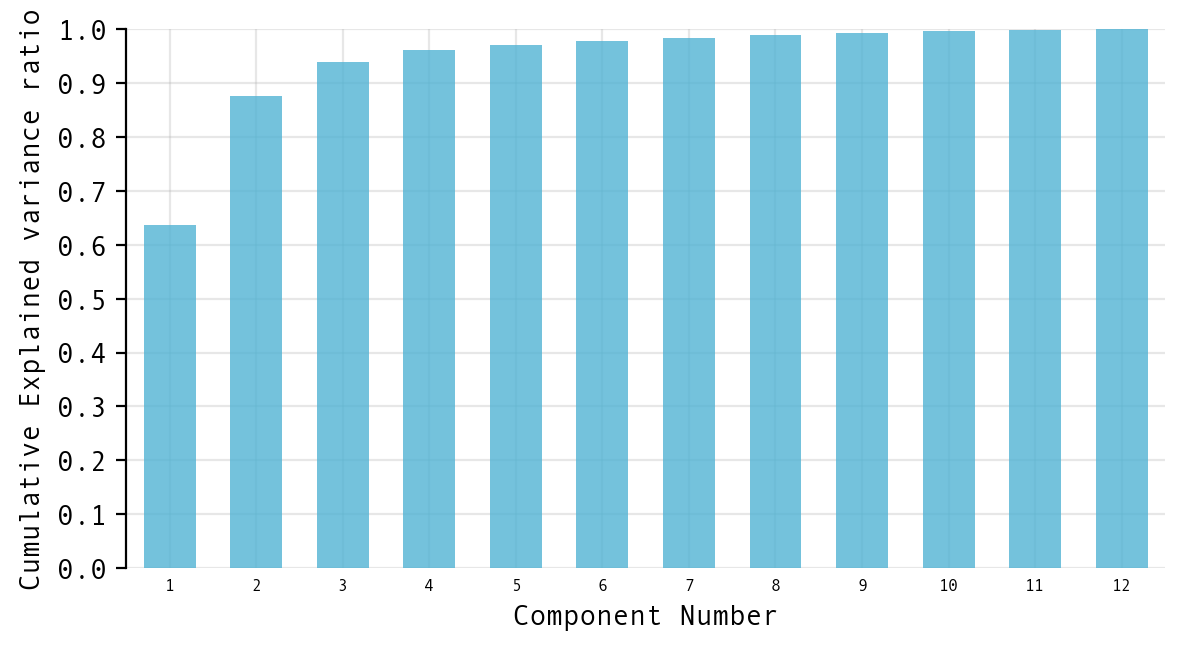

In [7]:
# Variance explained — without rotation correction
plot_explained(uncorrected_pca.explained_variance_ratio_, colour_before=0, annotate=False)


(<Figure size 670x350 with 1 Axes>,
 <Axes: xlabel='Component Number', ylabel='Cumulative Explained variance ratio'>)

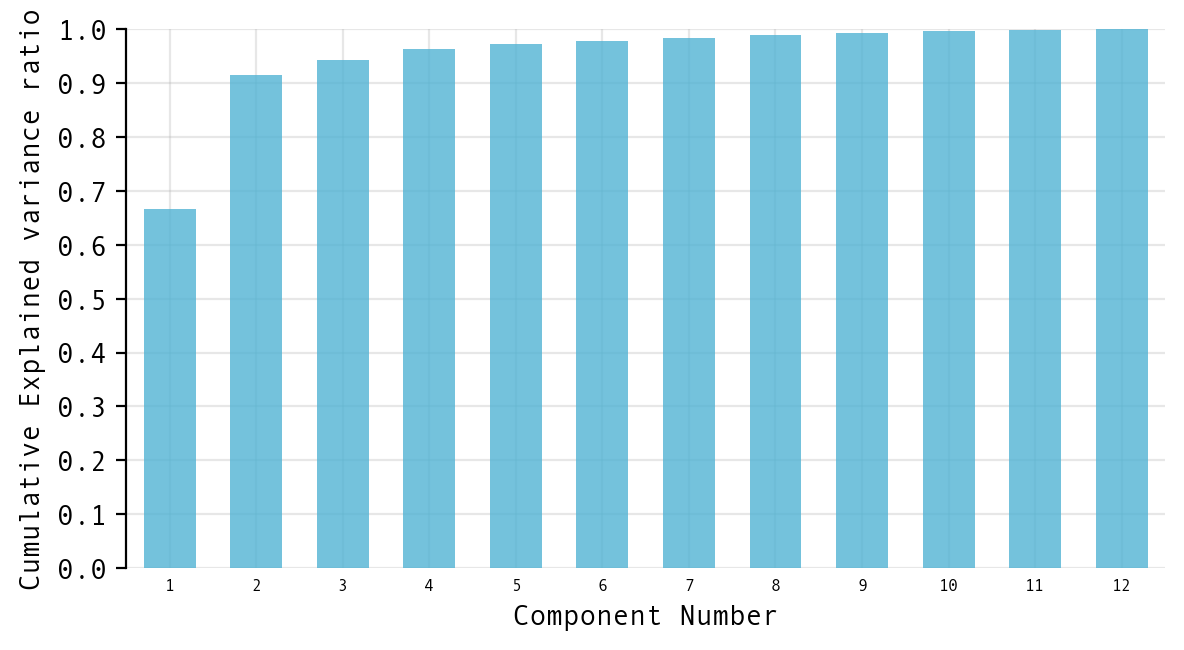

In [8]:
# Variance explained — with rotation correction
plot_explained(corrected_pca.explained_variance_ratio_, colour_before=0, annotate=False)
# plt.title("With rotation correction")

In [9]:
# Tabulate comparison
print(f"{'k':>3}  {'Uncorrected':>12}  {'Corrected':>12}  {'Difference':>12}")
print("-" * 45)
for i in range(12):
    diff = corrected_cev[i] - uncorrected_cev[i]
    print(f"{i+1:>3}  {uncorrected_cev[i]:>12.4f}  {corrected_cev[i]:>12.4f}  {diff:>+12.4f}")

  k   Uncorrected     Corrected    Difference
---------------------------------------------
  1        0.6367        0.6658       +0.0291
  2        0.8752        0.9150       +0.0397
  3        0.9394        0.9420       +0.0027
  4        0.9609        0.9633       +0.0024
  5        0.9711        0.9718       +0.0007
  6        0.9780        0.9785       +0.0004
  7        0.9837        0.9843       +0.0006
  8        0.9889        0.9893       +0.0004
  9        0.9929        0.9931       +0.0002
 10        0.9961        0.9961       +0.0000
 11        0.9985        0.9984       -0.0000
 12        1.0000        1.0000       -0.0000


<a id="comparing-component-loadings"></a>
## Comparing component loadings

We compare the component loadings using:

1. **Absolute dot products** between corresponding modes — the diagonal of the matrix shows how well each mode is preserved by the rotation correction.
2. **Principal cosines** — a rotation-invariant measure of subspace alignment (next section).

Saved: ../../figures/supplementary/S07_dotproducts_before_after.pdf


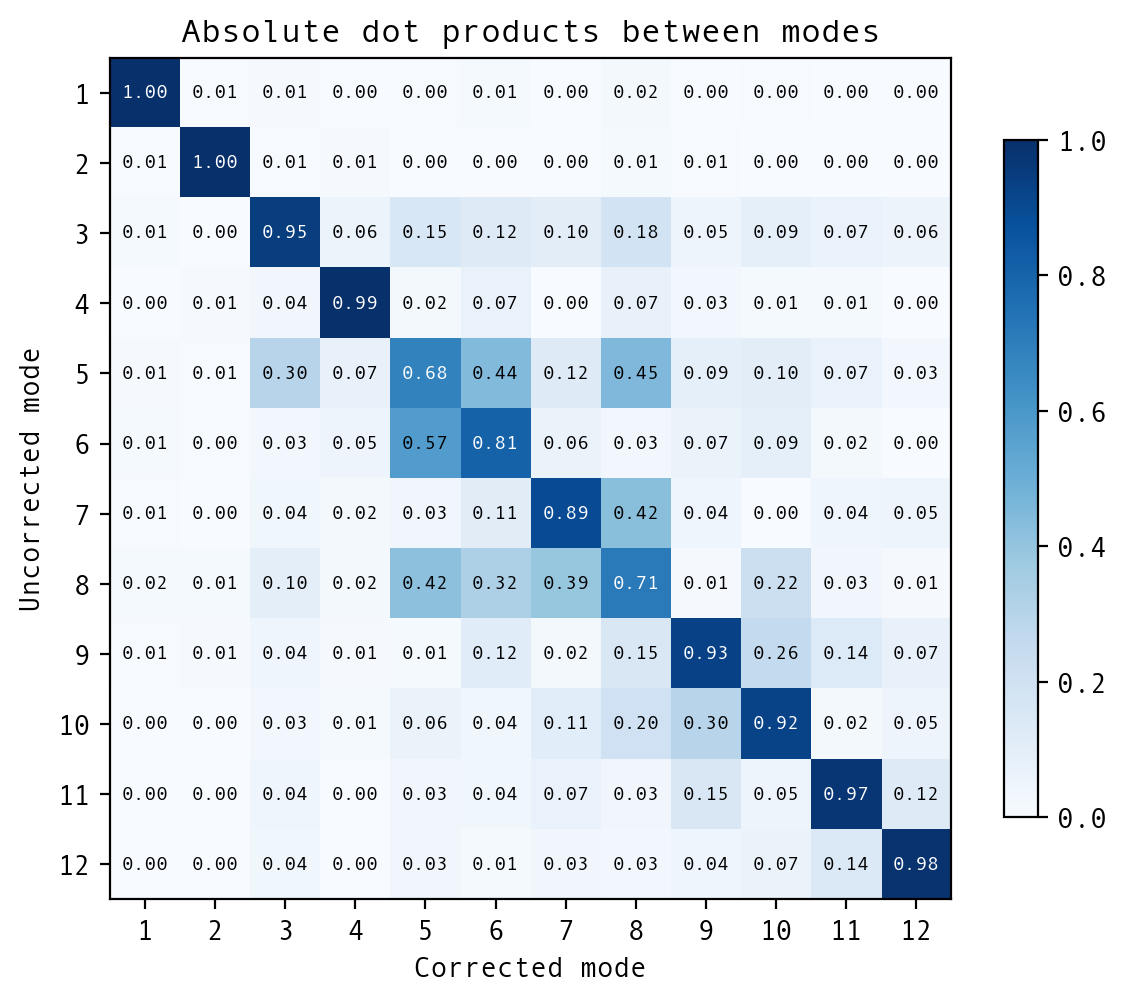


Diagonal (corresponding mode alignment):
  Mode 1: 1.000
  Mode 2: 1.000
  Mode 3: 0.945
  Mode 4: 0.994
  Mode 5: 0.682
  Mode 6: 0.805
  Mode 7: 0.894
  Mode 8: 0.714
  Mode 9: 0.933
  Mode 10: 0.923
  Mode 11: 0.974
  Mode 12: 0.985


In [10]:
# Compute absolute dot products between corresponding modes
dot_matrix = np.abs(uncorrected_pcs @ corrected_pcs.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dot_matrix, cmap='Blues', vmin=0, vmax=1, aspect='equal')

for i in range(12):
    for j in range(12):
        val = dot_matrix[i, j]
        colour = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                fontsize=7, color=colour)

ax.set_xlabel("Corrected mode")
ax.set_ylabel("Uncorrected mode")
ax.set_title("Absolute dot products between modes")
ax.set_xticks(range(12))
ax.set_xticklabels([f"{i+1}" for i in range(12)])
ax.set_yticks(range(12))
ax.set_yticklabels([f"{i+1}" for i in range(12)])
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

save_figure(fig, '../../figures/supplementary/S07_dotproducts_before_after.pdf')
plt.show()

# Report diagonal values
print("\nDiagonal (corresponding mode alignment):")
diag = np.diag(dot_matrix)
for i in range(12):
    print(f"  Mode {i+1}: {diag[i]:.3f}")

### Principal cosines

Principal cosines provide a rotation-invariant measure of subspace alignment.  For each subspace dimension *k*, we compute the principal cosines between the *k*-dimensional subspaces spanned by the leading *k* modes of each basis.  The **minimum** cosine at each *k* is the bottleneck: a value near 1.0 means the two *k*-dimensional subspaces are genuinely aligned; a drop indicates where the subspaces begin to diverge.

> **Note on dimension counting:** Two *k*-dimensional subspaces of ℝⁿ must share at least max(0, 2*k* − *n*) dimensions, so that many principal cosines are *guaranteed* to be 1.0 regardless of the data.  With *n* = 12 features and *k* = 12, *all* cosines would be trivially 1.0 for any two bases.  The sweep approach below avoids this pitfall by comparing subspaces of dimension *k* = 1, 2, …, 6 (i.e. *k* ≤ *n*/2), where no cosines are forced to be 1.0.

In [11]:
# Principal cosines between uncorrected and corrected subspaces
# Components are (n_components, n_features); transpose to (n_features, n_components)
n_features = uncorrected_pcs.shape[1]
max_k = n_features // 2  # compare up to n/2 to avoid trivial 1.0s

print("Principal cosines — sweep over subspace dimension k:")
print(f"  (n_features = {n_features}, comparing k = 1..{max_k})\n")
print(f"{'k':>3}  {'Min cosine':>10}  Note")
print("-" * 40)

for k in range(1, max_k + 1):
    cosines_k = principal_cosines(
        uncorrected_pcs.T, corrected_pcs.T, modes=k
    )
    min_cos = cosines_k[-1]  # worst alignment at this subspace dimension
    note = ""
    if min_cos > 1.0 - 1e-6:
        note = "(identical subspaces)"
    elif min_cos > 0.99:
        note = "(near-identical)"
    print(f"{k:>3}  {min_cos:>10.6f}  {note}")

Principal cosines — sweep over subspace dimension k:
  (n_features = 12, comparing k = 1..6)

  k  Min cosine  Note
----------------------------------------
  1    0.999551  (near-identical)
  2    0.999461  (near-identical)
  3    0.945258  
  4    0.942872  
  5    0.692646  
  6    0.830580  


<a id="comparing-score-traces"></a>
## Comparing score traces

The morphing shape mode scores describe how wing-tail configuration evolves during flight. We compare the score traces before and after rotation correction for a sample flight to check that the time-varying morphing patterns are preserved.

In [ ]:
# Score traces — uncorrected
uncorrected_scores_df, _ = get_score_df(
    uncorrected_scores, uncorrected_frame_info, size_bin=0.07
)

# Score traces — corrected
corrected_scores_df, _ = get_score_df(
    corrected_scores, unilateral_frame_info, size_bin=0.07
)

# Negate PC07 (m-folding) for interpretability: positive = more folded
uncorrected_scores_df["PC07"] = -uncorrected_scores_df["PC07"]
corrected_scores_df["PC07"] = -corrected_scores_df["PC07"]

# Save uncorrected scores for reference
uncorrected_scores_df.to_csv(
    "../../data/processed/scores_df_unilateral_no_rotation.csv", index=False
)

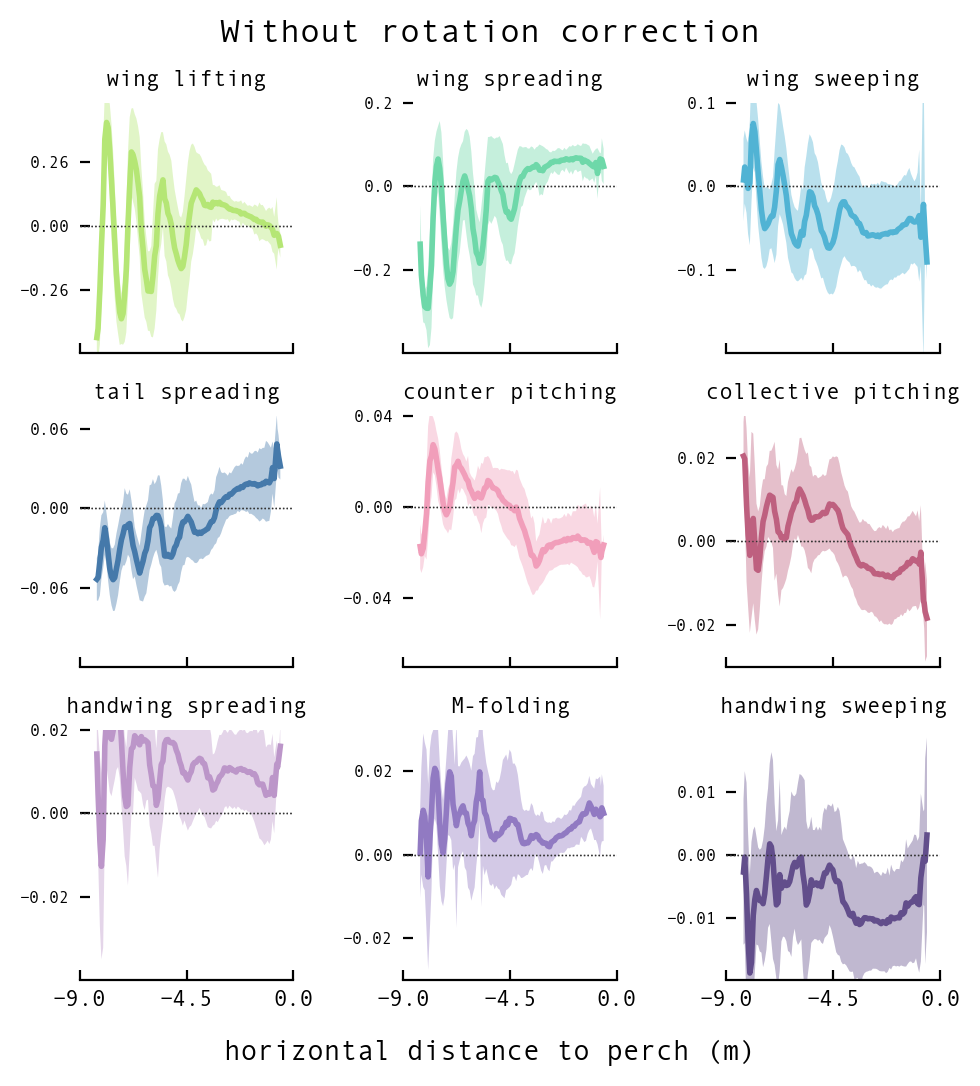

In [13]:
# Score traces — without rotation correction
# Toothless, 9 m, straight flights
plot_score_multi_PCs(uncorrected_scores_df, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Straight", year=2020)
plt.suptitle("Without rotation correction", y=1.02)
plt.show()

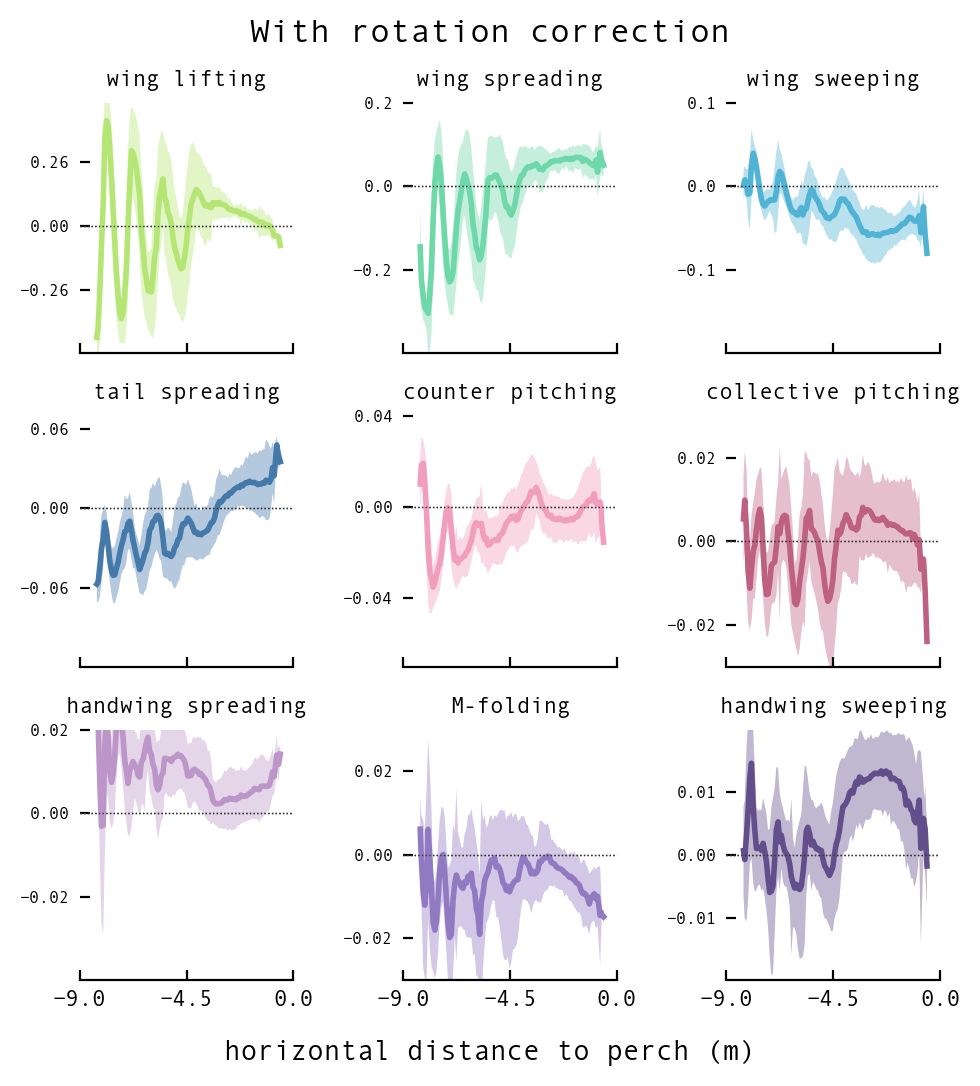

In [14]:
# Score traces — with rotation correction
# Toothless, 9 m, straight flights
plot_score_multi_PCs(corrected_scores_df, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Straight", year=2020)
plt.suptitle("With rotation correction", y=1.02)
plt.show()

## Summary

Comparing PCA before and after Kabsch rotation correction:

- **Variance explained** is similar in both cases: the first four modes capture ~96% of variance regardless of rotation correction.
- **The first two modes are virtually identical** (dot products ≥ 0.99), confirming that wing lifting and wing spreading — the dominant morphing patterns — are unaffected by the rotation correction.
- **Higher modes show moderate differences** (dot products 0.65–0.99), consistent with the removal of whole-body rotation from modes that previously mixed rotation with morphing.
- **Principal cosines** (sweeping subspace dimension *k* = 1…6, where no values are trivially guaranteed) confirm genuine alignment of the leading subspaces.

The rotation correction does not create new structure; it separates existing morphing variation from whole-body rotation, resulting in cleaner modes from PC 3 onwards. This is why the corrected data is used for all subsequent analysis.

---

## References

- Kabsch, W. (1976). A solution for the best rotation to relate two sets of vectors. *Acta Crystallographica Section A*, 32, 922–923.
- Björck, Å. & Golub, G. H. (1973). Numerical methods for computing angles between linear subspaces. *Mathematics of Computation*, 27, 579–594.